# PHASE 3: Univariate Analysis (One feature at a time)

## Goal:

Analyze one feature at a time and answer:

- What does it look like?
- What's the distribution?
- Is it skewed?
- Are there outliers?
- Does it make sense?
- Does it need preprocessing later?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as st
import seaborn as sns

In [2]:
# 3.0 data loading (load from phase 2- cleaned dataset)

df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\processed\EDA\01_eda_Phase-2_processed.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   latitude                 1471 non-null   float64
 1   longitude                1471 non-null   float64
 2   locality                 1471 non-null   str    
 3   gender                   1471 non-null   str    
 4   available_for            1471 non-null   str    
 5   transit_score            1471 non-null   float64
 6   lifestyle_score          1471 non-null   float64
 7   occupancy                1471 non-null   str    
 8   rent                     1471 non-null   float64
 9   deposit                  1471 non-null   float64
 10  attached_bathroom        1471 non-null   bool   
 11  food_included            1471 non-null   bool   
 12  breakfast                1471 non-null   bool   
 13  lunch                    1471 non-null   bool   
 14  dinner                   1471 non-n

In [3]:
# 3.1 Seperate Columns

num_cols = df.select_dtypes(include=['number']).columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.to_list()

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_12704\671289138.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.to_list()


# 3.1 univariate analysis for Numerical columns

In [4]:
# helper functions

def analyze_numeric(df: pd.DataFrame, column):
    """
    Perform univariate analysis on a numerical column.
    Displays:
    - Histogram + KDE
    - Boxplot
    - Summary statistics
    - Five-number summary
    - Distribution metrics
    - Outlier statistics (IQR method)
    """
    data = df[column]
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1,2, figsize=(14, 5))

    # histogram
    """
    CONCEPT: Histogram + KDE

    A histogram divides values into bins (ranges) and counts how many
    rows fall into each bin. Taller bars = more listings at that rent level.
    """

    sns.histplot(
        data = df,
        x = column,
        bins = 30,
        kde = True,
        ax = axes[0]
    )
    axes[0].set_title(f'{column} Distribution')
    axes[0].set_xlabel(column)

    # Boxplot
    
    """    
    CONCEPT: Box Plot
    A box plot shows the same data in a different way:

    - The box covers the middle 50% of values (25th to 75th percentile)
    - The line inside the box = median (50th percentile)
    - The whiskers extend to 1.5x the box height above and below
    - Dots beyond the whiskers = outliers
    """

    sns.boxplot(
        data = df,
        x = column,
        ax = axes[1]
    )

    axes[1].set_title(f'{column} Boxplot')

    plt.tight_layout()
    plt.show()
    plt.close()

    # Five Number Summary
    minimum = data.min()
    Q1 = data.quantile(0.25)
    median = data.median()
    Q3 = data.quantile(0.75)
    maximum = data.max()

    # IQR
    IQR = Q3 - Q1
    LOWER_FENCE = Q1 - 1.5 * IQR
    UPPER_FENCE = Q3 + 1.5 * IQR

    OUTLIERS = data[
        (data < LOWER_FENCE) | (data > UPPER_FENCE)
    ]

    # Statistics
    print("=" * 50)
    print(f"{column.upper()}")
    print("=" * 50)

    print("\nBasic Statistics")
    print("-" * 25)
    print(f"Count      : {data.count()}")
    print(f"Missing    : {df[column].isna().sum()}")
    print(f"Mean       : {data.mean():.2f}")
    print(f"Median     : {median:.2f}")
    print(f"Mode       : {data.mode().iloc[0]}")
    print(f"Std Dev    : {data.std():.2f}")

    print("\nFive Number Summary")
    print("-" * 25)
    print(f"Minimum    : {minimum}")
    print(f"Q1 (25%)   : {Q1}")
    print(f"Median     : {median}")
    print(f"Q3 (75%)   : {Q3}")
    print(f"Maximum    : {maximum}")

    print("\nDistribution")
    print("-" * 25)
    print(f"Skewness   : {data.skew():.2f}")
    print(f"Kurtosis   : {data.kurt():.2f}")

    print("\nOutlier Analysis (IQR Method)")
    print("-" * 25)
    print(f"IQR            : {IQR:.2f}")
    print(f"Lower Bound    : {LOWER_FENCE:.2f}")
    print(f"Upper Bound    : {UPPER_FENCE:.2f}")
    print(f"No. of Outliers: {len(OUTLIERS)}")
    print(f"% of Outliers  : {(len(OUTLIERS)/len(data))*100:.2f}%")

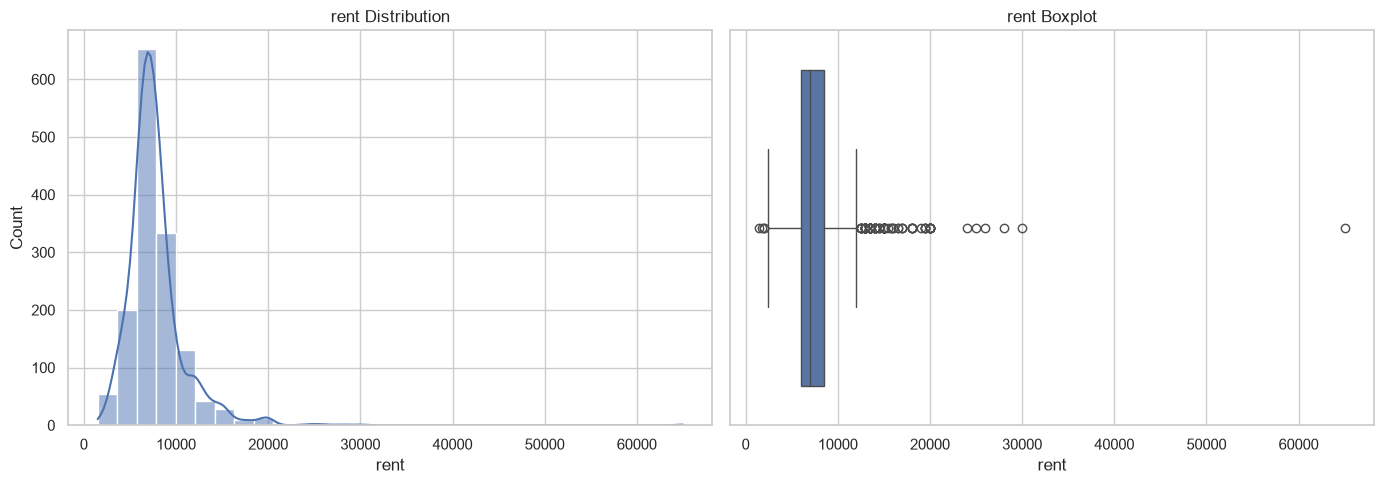

RENT

Basic Statistics
-------------------------
Count      : 1471
Missing    : 0
Mean       : 7779.39
Median     : 7000.00
Mode       : 6500.0
Std Dev    : 3321.23

Five Number Summary
-------------------------
Minimum    : 1500.0
Q1 (25%)   : 6000.0
Median     : 7000.0
Q3 (75%)   : 8500.0
Maximum    : 65000.0

Distribution
-------------------------
Skewness   : 4.92
Kurtosis   : 64.07

Outlier Analysis (IQR Method)
-------------------------
IQR            : 2500.00
Lower Bound    : 2250.00
Upper Bound    : 12250.00
No. of Outliers: 104
% of Outliers  : 7.07%


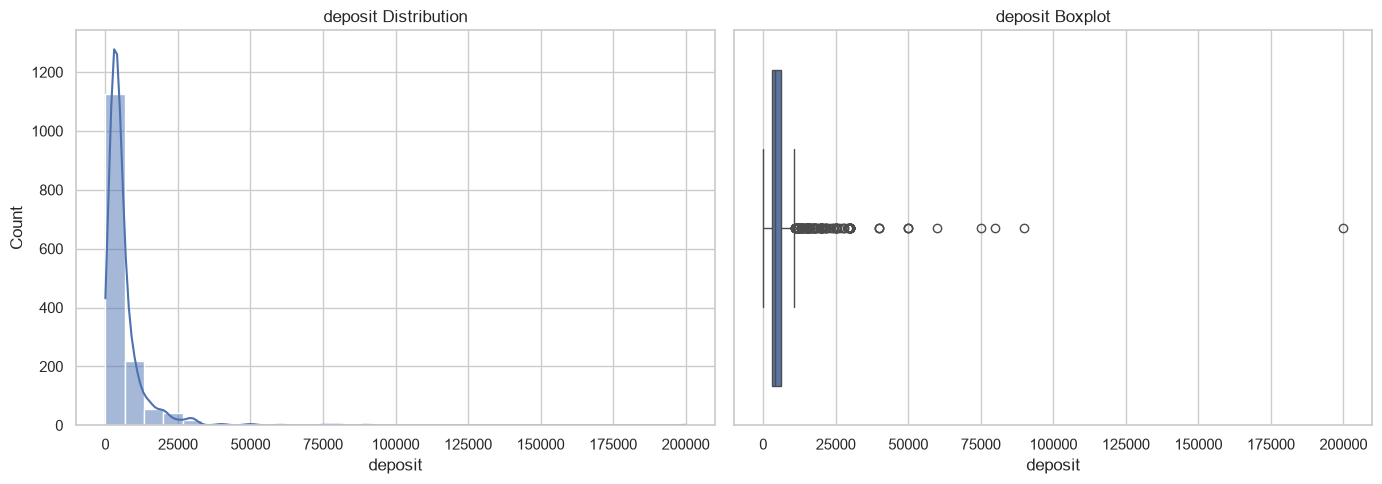

DEPOSIT

Basic Statistics
-------------------------
Count      : 1471
Missing    : 0
Mean       : 6104.53
Median     : 4000.00
Mode       : 3000.0
Std Dev    : 8440.18

Five Number Summary
-------------------------
Minimum    : 0.0
Q1 (25%)   : 3000.0
Median     : 4000.0
Q3 (75%)   : 6000.0
Maximum    : 200000.0

Distribution
-------------------------
Skewness   : 10.84
Kurtosis   : 205.34

Outlier Analysis (IQR Method)
-------------------------
IQR            : 3000.00
Lower Bound    : -1500.00
Upper Bound    : 10500.00
No. of Outliers: 164
% of Outliers  : 11.15%


In [18]:
# Rent & deposit

columns = ['rent', 'deposit']
for col in columns:
    analyze_numeric(df, col)

# Observations:

- Rent is positively skewed — most PGs sit in the lower range, a small tail of premium properties pushes price up. These upper listings look realistic, not erroneous, and should stay in.
- Deposit tops out at ₹2 lakh; the dataset has some luxury PGs so this is plausible, not a data-entry error.

## Decision: 
- retain outliers in both columns as genuine premium-segment signal. No filtering. Skew is a preprocessing-stage concern (log1p), not a cleaning-stage one.


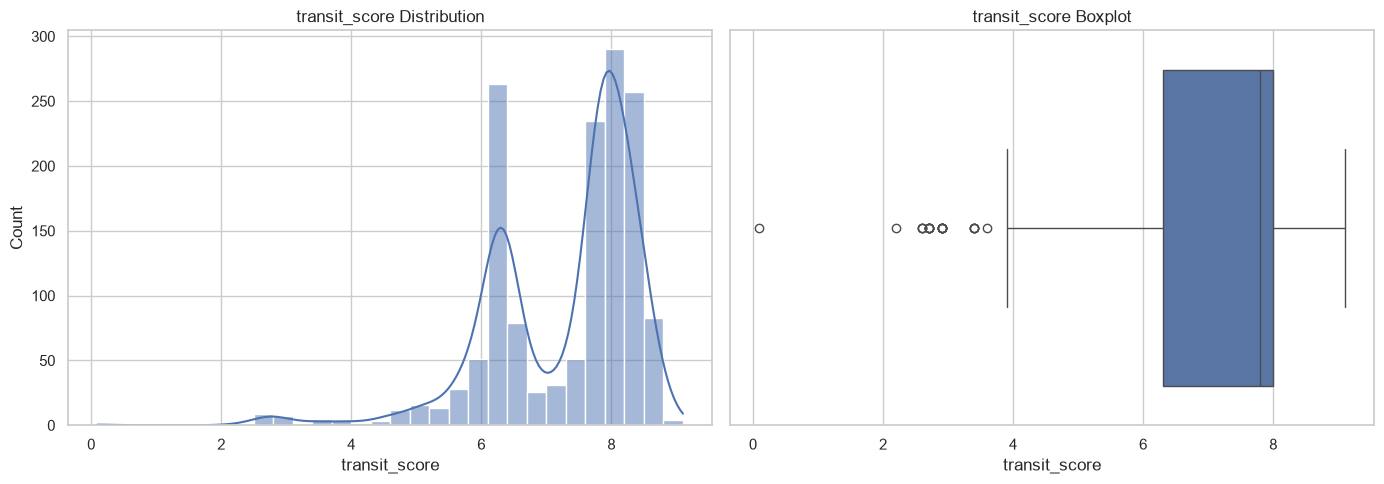

TRANSIT_SCORE

Basic Statistics
-------------------------
Count      : 1471
Missing    : 0
Mean       : 7.28
Median     : 7.80
Mode       : 7.8
Std Dev    : 1.13

Five Number Summary
-------------------------
Minimum    : 0.1
Q1 (25%)   : 6.3
Median     : 7.8
Q3 (75%)   : 8.0
Maximum    : 9.1

Distribution
-------------------------
Skewness   : -1.42
Kurtosis   : 3.03

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.70
Lower Bound    : 3.75
Upper Bound    : 10.55
No. of Outliers: 23
% of Outliers  : 1.56%


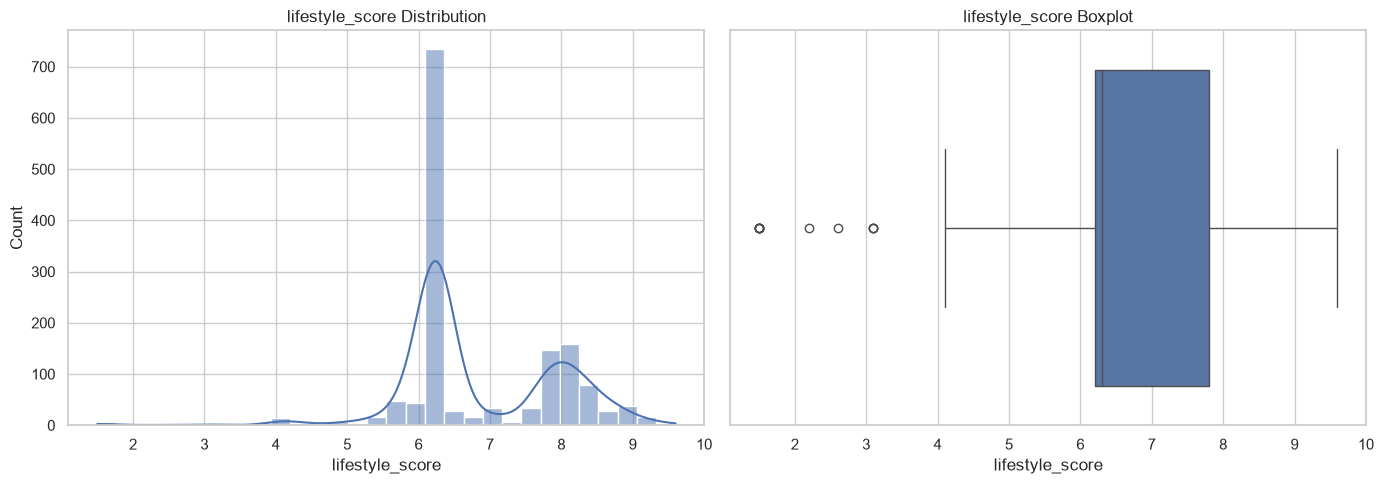

LIFESTYLE_SCORE

Basic Statistics
-------------------------
Count      : 1471
Missing    : 0
Mean       : 6.83
Median     : 6.30
Mode       : 6.3
Std Dev    : 1.11

Five Number Summary
-------------------------
Minimum    : 1.5
Q1 (25%)   : 6.2
Median     : 6.3
Q3 (75%)   : 7.8
Maximum    : 9.6

Distribution
-------------------------
Skewness   : -0.22
Kurtosis   : 1.67

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.60
Lower Bound    : 3.80
Upper Bound    : 10.20
No. of Outliers: 11
% of Outliers  : 0.75%


In [5]:
# Scores

columns = ['transit_score', 'lifestyle_score']
for col in columns:
    analyze_numeric(df, col)

# Observation

## Transit score
- Transit scores are concentrated between 6 and 8, suggesting that most PGs are located in moderately accessible areas. Very low transit scores are uncommon.
## Lifestyle Score
- looks normal, mostly around 5.5 - 9
- 6.1 - 6.3 has most (~700)

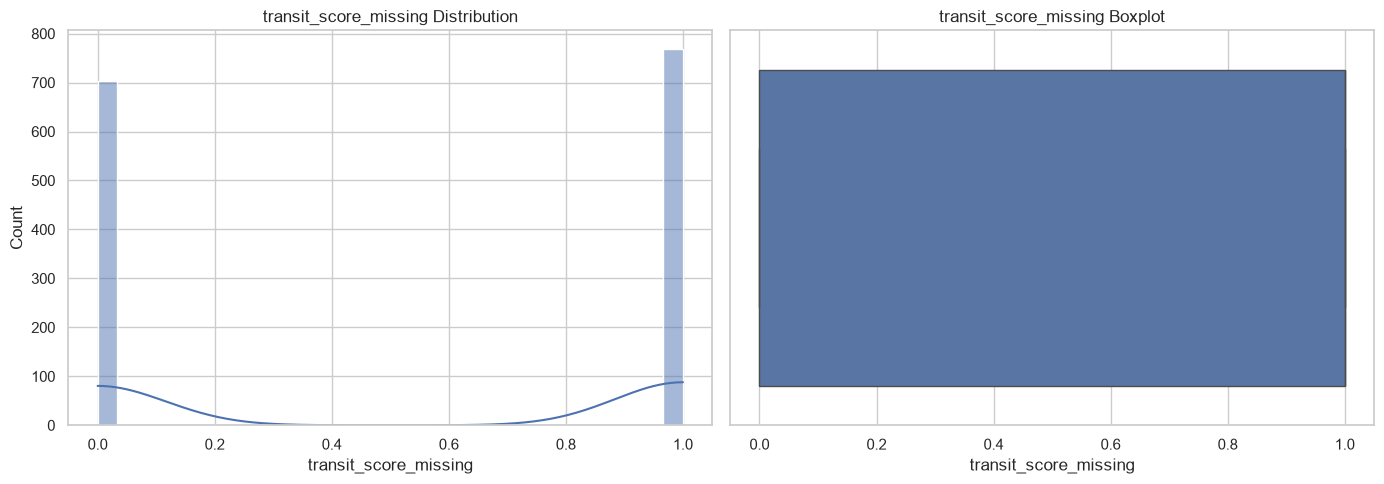

TRANSIT_SCORE_MISSING

Basic Statistics
-------------------------
Count      : 1471
Missing    : 0
Mean       : 0.52
Median     : 1.00
Mode       : 1
Std Dev    : 0.50

Five Number Summary
-------------------------
Minimum    : 0
Q1 (25%)   : 0.0
Median     : 1.0
Q3 (75%)   : 1.0
Maximum    : 1

Distribution
-------------------------
Skewness   : -0.09
Kurtosis   : -1.99

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.00
Lower Bound    : -1.50
Upper Bound    : -0.50
No. of Outliers: 1471
% of Outliers  : 100.00%


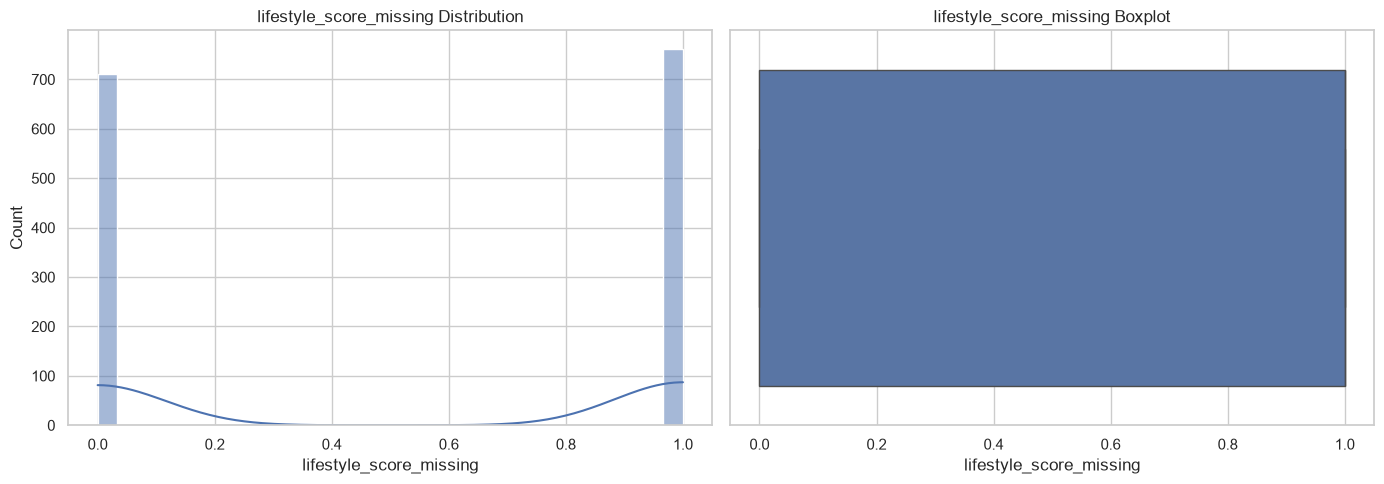

LIFESTYLE_SCORE_MISSING

Basic Statistics
-------------------------
Count      : 1471
Missing    : 0
Mean       : 0.52
Median     : 1.00
Mode       : 1
Std Dev    : 0.50

Five Number Summary
-------------------------
Minimum    : 0
Q1 (25%)   : 0.0
Median     : 1.0
Q3 (75%)   : 1.0
Maximum    : 1

Distribution
-------------------------
Skewness   : -0.07
Kurtosis   : -2.00

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.00
Lower Bound    : -1.50
Upper Bound    : -0.50
No. of Outliers: 1471
% of Outliers  : 100.00%


In [8]:
# Scores missing tag

columns = ['transit_score_missing', 'lifestyle_score_missing']
for col in columns:
    analyze_numeric(df, col)

# Obsevation

I should avoided this, 

# Summary

### Key Findings

- Rent and deposit are positively skewed.
- Premium listings create realistic upper-end outliers.
- Transit and lifestyle scores are approximately normally distributed.
- No numerical feature contains severe anomalies requiring removal.
- Skewed variables may benefit from transformation during preprocessing.

# 3.2 Univariate Analysis for Categorical Column

In [6]:
# helper function

def analyze_categorical(df, column):
    counts = df[column].value_counts(dropna=False) # dropna not needed because it is cleaned dataset
    percentages = df[column].value_counts(normalize=True, dropna=False) * 100

    summary = (
        pd.DataFrame({
            "Count": counts,
            "Percentage": percentages.round(2)
        })
    )

    print(f"\n===== {column} =====")
    display(summary)

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

    print(f"Unique Categories : {df[column].nunique()}")
    print(f"Missing Values    : {df[column].isna().sum()}")

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   latitude                 1471 non-null   float64
 1   longitude                1471 non-null   float64
 2   locality                 1471 non-null   str    
 3   gender                   1471 non-null   str    
 4   available_for            1471 non-null   str    
 5   transit_score            1471 non-null   float64
 6   lifestyle_score          1471 non-null   float64
 7   occupancy                1471 non-null   str    
 8   rent                     1471 non-null   float64
 9   deposit                  1471 non-null   float64
 10  attached_bathroom        1471 non-null   bool   
 11  food_included            1471 non-null   bool   
 12  breakfast                1471 non-null   bool   
 13  lunch                    1471 non-null   bool   
 14  dinner                   1471 non-n


===== locality =====


,Count,Percentage
locality,,
Tharamani,240,16.32
OMR-Karappakam,232,15.77
Velachery,192,13.05
Sholinganallur,94,6.39
Tambaram,63,4.28
East Coast Road-Thiruvanmiyur,63,4.28
Saidapet,61,4.15
Vadapalani,54,3.67
New Perungalathur,47,3.20


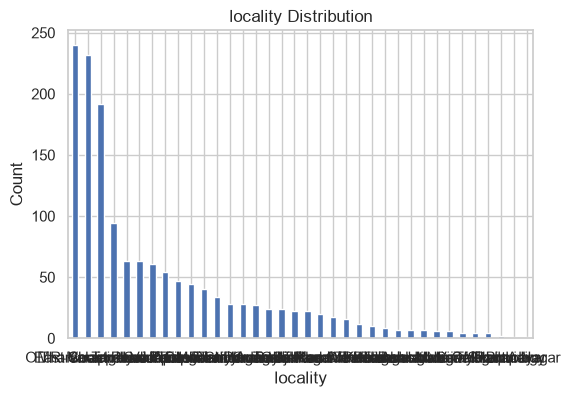

Unique Categories : 36
Missing Values    : 0


In [19]:
analyze_categorical(df, column=('locality'))

# Observation 

- i can see the imbalnce in the locality, while few (apparently top 3) ranges between 190 - 240, and the rest are below 95
- apparently 24 locality lies between 1 - 50


===== gender =====


,Count,Percentage
gender,,
MALE,770,52.35
FEMALE,661,44.94
BOTH,40,2.72


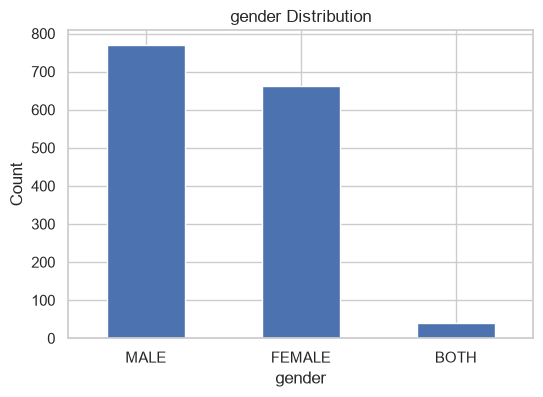

Unique Categories : 3
Missing Values    : 0


In [20]:
analyze_categorical(df, column=('gender'))

# Observation 

- This looks geniune, Female and Male roughly equals, while `BOTH` on the edge.
- SO some PGs have provide for both gender so keep as it is


===== available_for =====


,Count,Percentage
available_for,,
Both,1307,88.85
Working Professional,139,9.45
Student,25,1.70


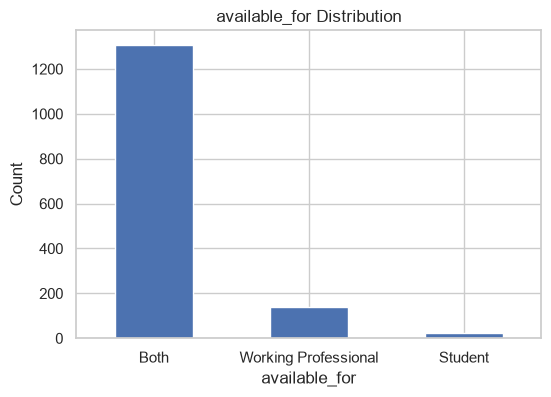

Unique Categories : 3
Missing Values    : 0


In [21]:
analyze_categorical(df, column=('available_for'))

# Observation

- Seems `BOTH` category leads, so i shoukd give a meaningful lable name
- and student and professional , leave as it is


===== occupancy =====


,Count,Percentage
occupancy,,
THREE,476,32.36
FOUR,402,27.33
DOUBLE,399,27.12
SINGLE,194,13.19


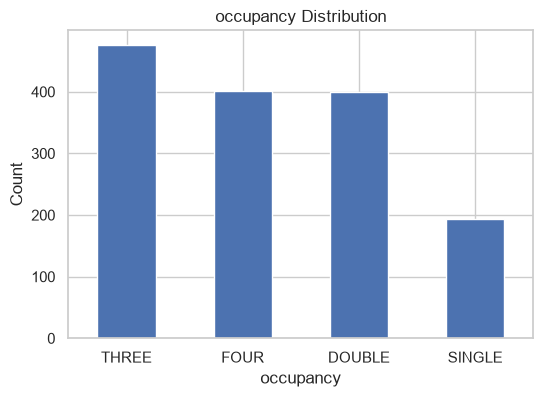

Unique Categories : 4
Missing Values    : 0


In [22]:
analyze_categorical(df, column=('occupancy'))

# Observation

- This is the Gold Feature lable for this project, and luckily it roughly eqauls to each other, except `Single`, 
- `Single` sharing COsts high, so it is less than others
- Should be leave as it is


===== parking =====


,Count,Percentage
parking,,
Bike,1170,79.54
none,144,9.79
Bike and Car,109,7.41
Car,48,3.26


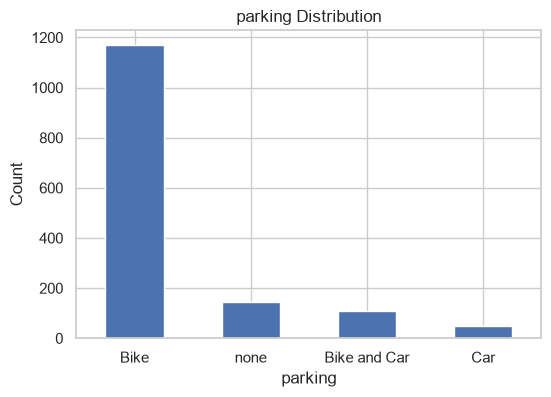

Unique Categories : 4
Missing Values    : 0


In [7]:
analyze_categorical(df, column=('parking'))

# Observation

- I can see the clear imbalnce here, and have 144 Nan values too, so heres my plan

```md
None          →  'No Parking'
Bike          →  'Parking Available'
Car           →  'Parking Available'
Bike and Car  →  'Parking Available'
```

# SUMMARY

- Should modify the Parking column
- Give a meaningful name for `BOTH` lable in available for -> `both` -> `anyone` 

# 3.3 univariate analysis for Boolean columns


===== attached_bathroom =====


,Count,Percentage
attached_bathroom,,
False,1157,78.65
True,314,21.35


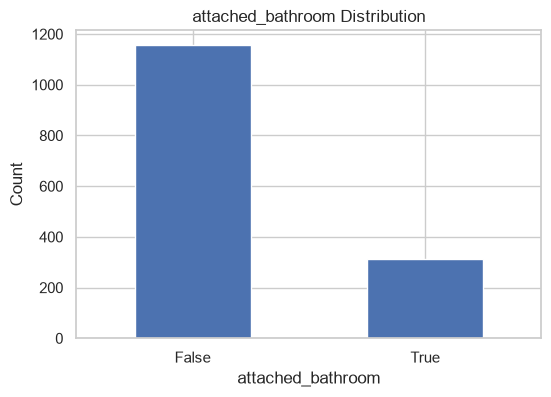

Unique Categories : 2
Missing Values    : 0

===== food_included =====


,Count,Percentage
food_included,,
True,1103,74.98
False,368,25.02


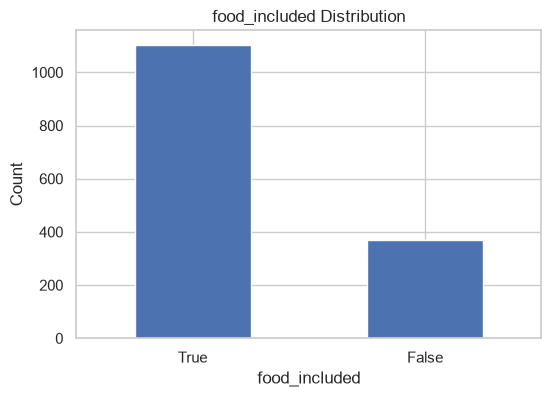

Unique Categories : 2
Missing Values    : 0

===== breakfast =====


,Count,Percentage
breakfast,,
True,1079,73.35
False,392,26.65


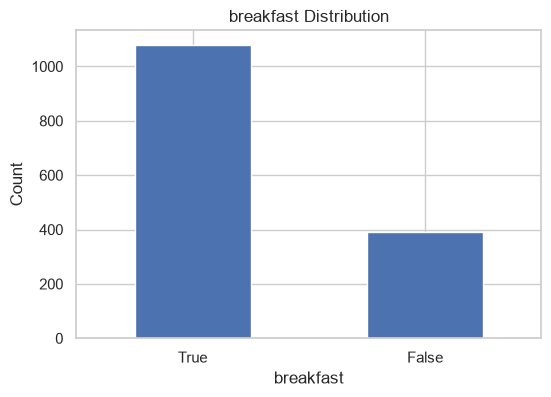

Unique Categories : 2
Missing Values    : 0

===== lunch =====


,Count,Percentage
lunch,,
True,1054,71.65
False,417,28.35


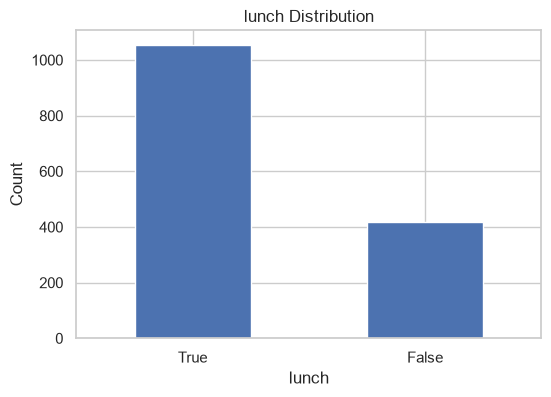

Unique Categories : 2
Missing Values    : 0

===== dinner =====


,Count,Percentage
dinner,,
True,1075,73.08
False,396,26.92


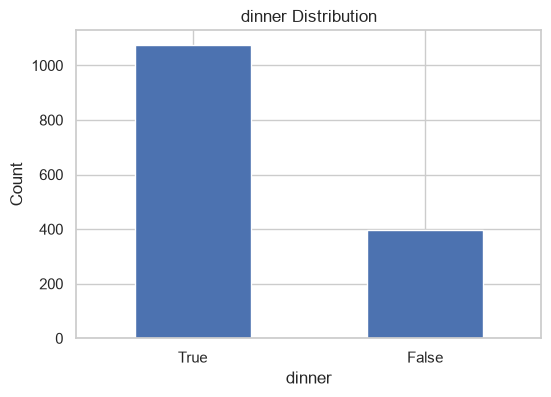

Unique Categories : 2
Missing Values    : 0

===== mess =====


,Count,Percentage
mess,,
False,1100,74.78
True,371,25.22


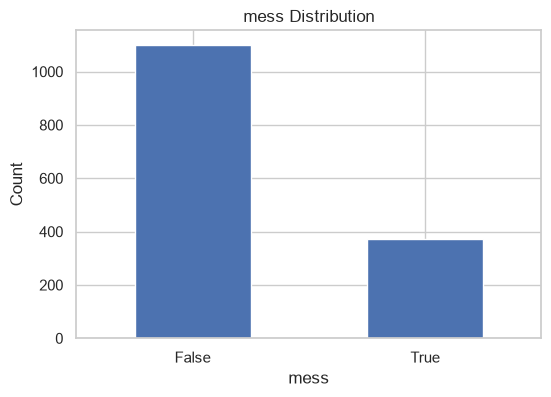

Unique Categories : 2
Missing Values    : 0

===== wifi =====


,Count,Percentage
wifi,,
False,839,57.04
True,632,42.96


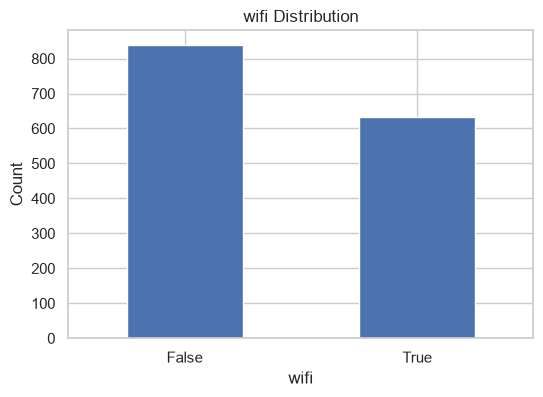

Unique Categories : 2
Missing Values    : 0

===== laundry =====


,Count,Percentage
laundry,,
False,1071,72.81
True,400,27.19


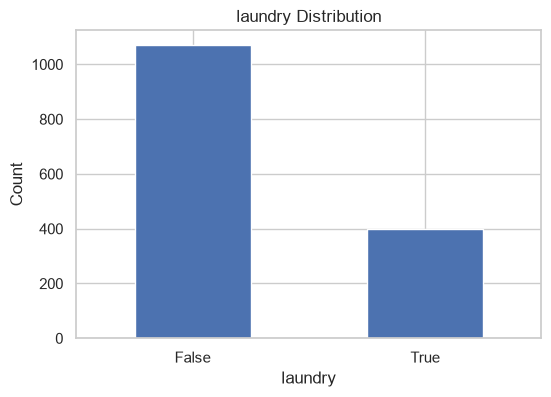

Unique Categories : 2
Missing Values    : 0

===== power_backup =====


,Count,Percentage
power_backup,,
False,1283,87.22
True,188,12.78


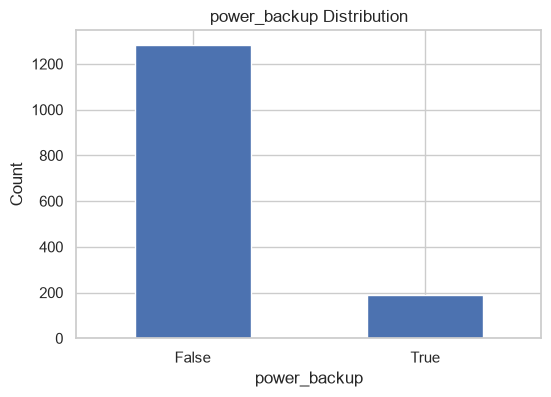

Unique Categories : 2
Missing Values    : 0

===== refrigerator =====


,Count,Percentage
refrigerator,,
False,998,67.85
True,473,32.15


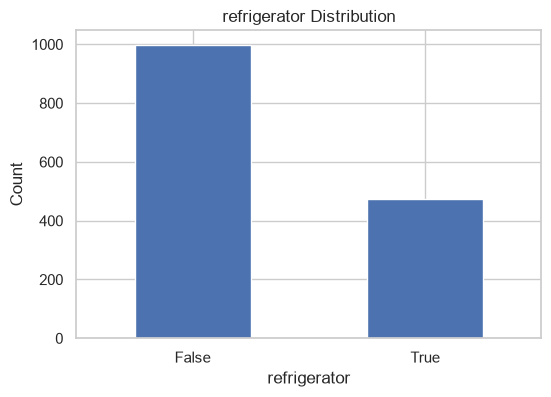

Unique Categories : 2
Missing Values    : 0

===== common_tv =====


,Count,Percentage
common_tv,,
False,1139,77.43
True,332,22.57


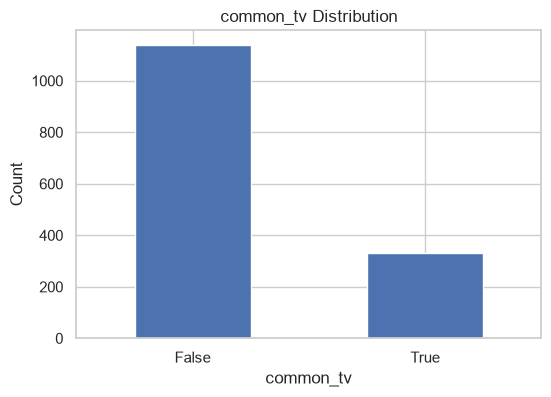

Unique Categories : 2
Missing Values    : 0

===== room_cleaning =====


,Count,Percentage
room_cleaning,,
False,884,60.1
True,587,39.9


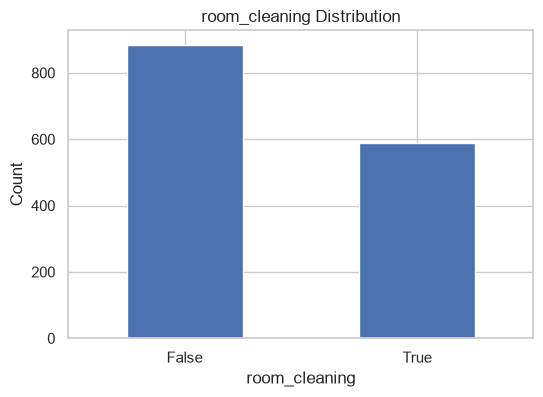

Unique Categories : 2
Missing Values    : 0

===== room_ac =====


,Count,Percentage
room_ac,,
False,1065,72.4
True,406,27.6


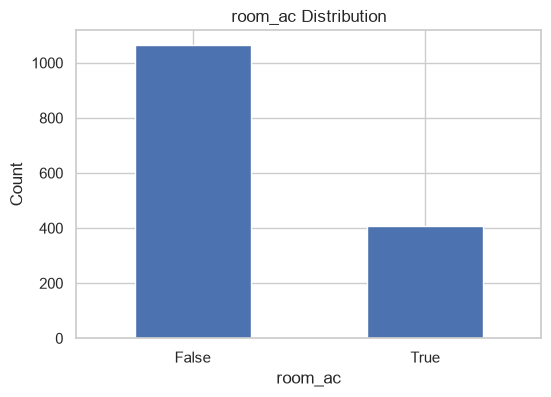

Unique Categories : 2
Missing Values    : 0

===== room_cupboard =====


,Count,Percentage
room_cupboard,,
False,1004,68.25
True,467,31.75


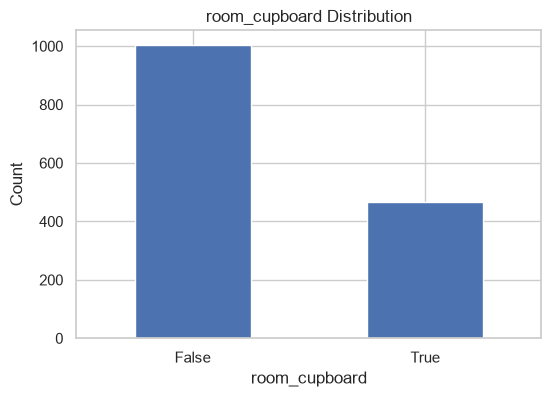

Unique Categories : 2
Missing Values    : 0

===== room_tv =====


,Count,Percentage
room_tv,,
False,1222,83.07
True,249,16.93


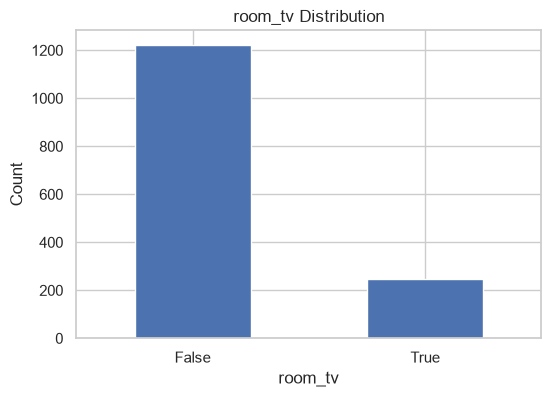

Unique Categories : 2
Missing Values    : 0

===== room_geyser =====


,Count,Percentage
room_geyser,,
False,1117,75.93
True,354,24.07


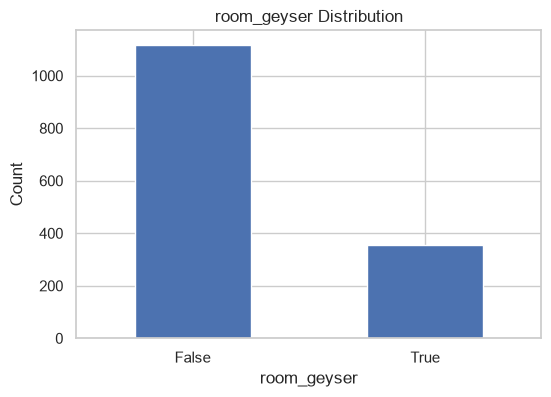

Unique Categories : 2
Missing Values    : 0

===== room_bedding =====


,Count,Percentage
room_bedding,,
False,1025,69.68
True,446,30.32


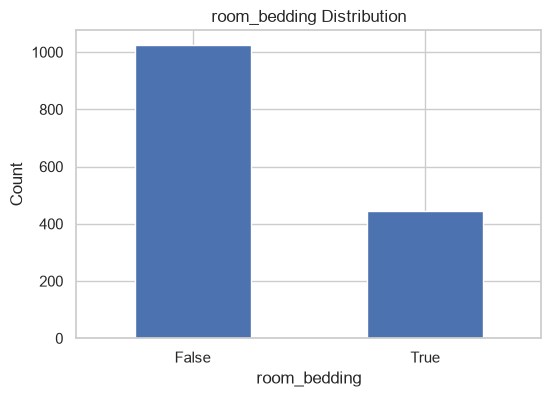

Unique Categories : 2
Missing Values    : 0

===== room_attached_bath =====


,Count,Percentage
room_attached_bath,,
False,1010,68.66
True,461,31.34


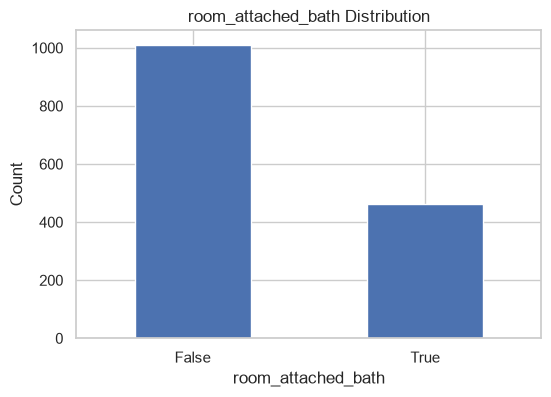

Unique Categories : 2
Missing Values    : 0


In [8]:
bool_col = df.select_dtypes(include=['bool']).columns.to_list()

for col in bool_col:
    analyze_categorical(df, column=(col))

# Observation

- All seems Good!
- And i can see that the `food_include` = `breakfast` , `lunch`, `dinner` are all almost identical.

```md
SO WHEN ~74% food_include TRUE, 
- brakefast ~73% True
- lunch ~71% True
- dinner ~74% True
```

## Decision:
- can drop the breakfast, kunch, dinner column safely

## 3.1 Numerical Columns

### Rent & Deposit (the two most important numeric columns)

| Metric | Rent | Deposit |
|---|---|---|
| Mean | 7,779.39 | 6,104.53 |
| Median | 7,000.00 | 4,000.00 |
| Mode | 6,500.00 | 3,000.00 |
| Std Dev | 3,321.23 | 8,440.18 |
| Min | 1,500 | 0 |
| Q1 | 6,000 | 3,000 |
| Q3 | 8,500 | 6,000 |
| Max | 65,000 | 200,000 |
| Skewness | 4.92 | 10.84 |
| Kurtosis | 64.07 | 205.34 |
| IQR Outliers | 104 (7.07%) | 164 (11.15%) |

**Observations:**
- Rent is positively skewed most PGs sit in the lower range, a small tail of premium properties pushes price up. These upper listings look realistic, not erroneous, and should stay in.
- Deposit tops out at ₹2 lakh; the dataset has some luxury PGs so this is plausible, not a data-entry error.

**Decision:** retain outliers in both columns as genuine premium-segment signal. No filtering. Skew is a preprocessing-stage concern (log1p), not a cleaning-stage one.

### Numerical Summary

- Rent and deposit are positively skewed with realistic, premium-driven upper outliers keep, transform later (log1p) if needed.
- Transit/lifestyle scores are roughly normal but their reported outlier stats are stale/wrong and need a re-run.
- No numeric feature needs row-level removal at this stage.
- Binary indicator columns should never go through the continuous-outlier helper again.

---

## 3.2 Categorical Columns

| Column | Unique Categories | Missing | Key Finding |
|---|---|---|---|
| `locality` | 36 | 0 | Heavily imbalanced see below |
| `gender` | 3 | 0 | Roughly balanced, `BOTH` is a small edge case |
| `available_for` | 3 | 0 | Dominated by one category see below |
| `occupancy` | 4 | 0 | Fairly balanced the "gold" feature for this project |
| `parking` | 3 | 144 | Imbalanced + real missingness |

### `locality` (36 categories)
Top 3 localities alone Tharamani (240, 16.3%), OMR-Karapakkam (232, 15.8%), Velachery (192, 13.1%) account for **~45% of all listings**. ~24 localities sit in the 1–50 row range (long tail).

**Decision:** keep locality (Phase 2 already committed to smoothed target encoding for it), but be aware the long tail means some encoded values will be built on very few observations worth a minimum-count floor or shrinkage-heavy smoothing when that encoding is actually fit.

### `gender`
MALE 770 (52.3%), FEMALE 661 (44.9%), BOTH 40 (2.7%). Genuinely balanced between Male/Female; `BOTH` is a real but small third option (mixed-gender PGs exist) keep as-is, no merging.

### `available_for`
Both 1,307 (**88.85%**), Working Professional 139 (9.45%), Student 25 (1.70%).

**Decision:** rename `Both` to a clearer label (e.g. `Anyone`) so it isn't confused with the `gender` column's `BOTH`. Also flag: at 88.85% concentration this is close to a near-zero-variance feature don't drop yet (Phase 4's box-plot shows it does move the rent mean), but keep it on the watchlist for the Phase 4 tree-based importance check.

### `occupancy`
THREE 476 (32.4%), FOUR 402 (27.3%), DOUBLE 399 (27.1%), SINGLE 194 (13.2%) reasonably balanced, with `SINGLE` naturally smaller since it costs more per bed.

**Decision:** leave as-is. This is the primary structural driver of rent (confirmed in Phase 4) do not encode away its ordinality carelessly; consider ordinal encoding (Single < Double < Three < Four) rather than plain one-hot, since it reflects a genuine sharing-count order.

### `parking`
Bike 1,170 (79.5%), NaN 144 (9.8%), Bike and Car 109 (7.4%), Car 48 (3.3%).

**Decision:** Phase 1 originally planned to encode parking as 4 ordinal levels (none/bike/car/both). 

---

## 3.3 Boolean Columns

All 15 boolean amenity columns were run through frequency analysis. Everything looked reasonable except one redundancy:

**`food_included` vs. `breakfast` / `lunch` / `dinner`:**

| Column | % True |
|---|---|
| food_included | ~74% |
| breakfast | ~73% |
| lunch | ~71% |
| dinner | ~74% |

These four are almost perfectly overlapping a PG that includes food essentially includes all three meals.

**Decision:** drop `breakfast`, `lunch`, `dinner`; keep `food_included` as the single representative feature. (This was executed at the top of the Phase 4 notebook via `df.drop(columns=['lunch','dinner','breakfast'])`.)

---

## Phase 3 Decisions to Carry Forward

| # | Decision | Status |
|---|---|---|
| 1 | Rename `available_for`'s `Both` → `Anyone` to avoid confusion with `gender`'s `BOTH` | Planned |
| 2 | Keep `available_for` despite 88.85% concentration  recheck importance in Phase 4| Watchlist |
| 3 | Drop `breakfast`, `lunch`, `dinner`; keep `food_included` | **Done** (executed in Phase 4 notebook) |
| 4 | Retain rent/deposit outliers as genuine premium signal  no row removal | Done (no action needed) |

---

> **Next:** `04_EDA_Phase4.ipynb`  bivariate analysis of every feature against `rent`.